In [1]:
import numpy as np
import pandas as pd
import sys,os
import csv
import string
import matplotlib.pyplot as plt
from scipy import stats
import seaborn
from pathlib import Path

In [2]:
WhichStory = 'prettymouthaffair'

textValueFileDF = pd.read_excel(f"/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/{WhichStory}_MFT_MAC.xlsx")

virtues = textValueFileDF[['MAC_a_fairness_virtue',
                               'MAC_a_group_virtue',
                               'MAC_a_deference_virtue',
                               'MAC_a_heroism_virtue',
                               'MAC_a_reciprocity_virtue',
                               'MAC_a_family_virtue',
                               'MAC_a_property_virtue']]

vices = textValueFileDF[['MAC_a_fairness_vice',
                               'MAC_a_group_vice',
                               'MAC_a_deference_vice',
                               'MAC_a_heroism_vice',
                               'MAC_a_reciprocity_vice',
                               'MAC_a_family_vice',
                               'MAC_a_property_vice']]

# output directory
base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

output_dir = Path(f"{base_dir1}/foundationScorePlots/")
output_dir

PosixPath('/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/foundationScorePlots')

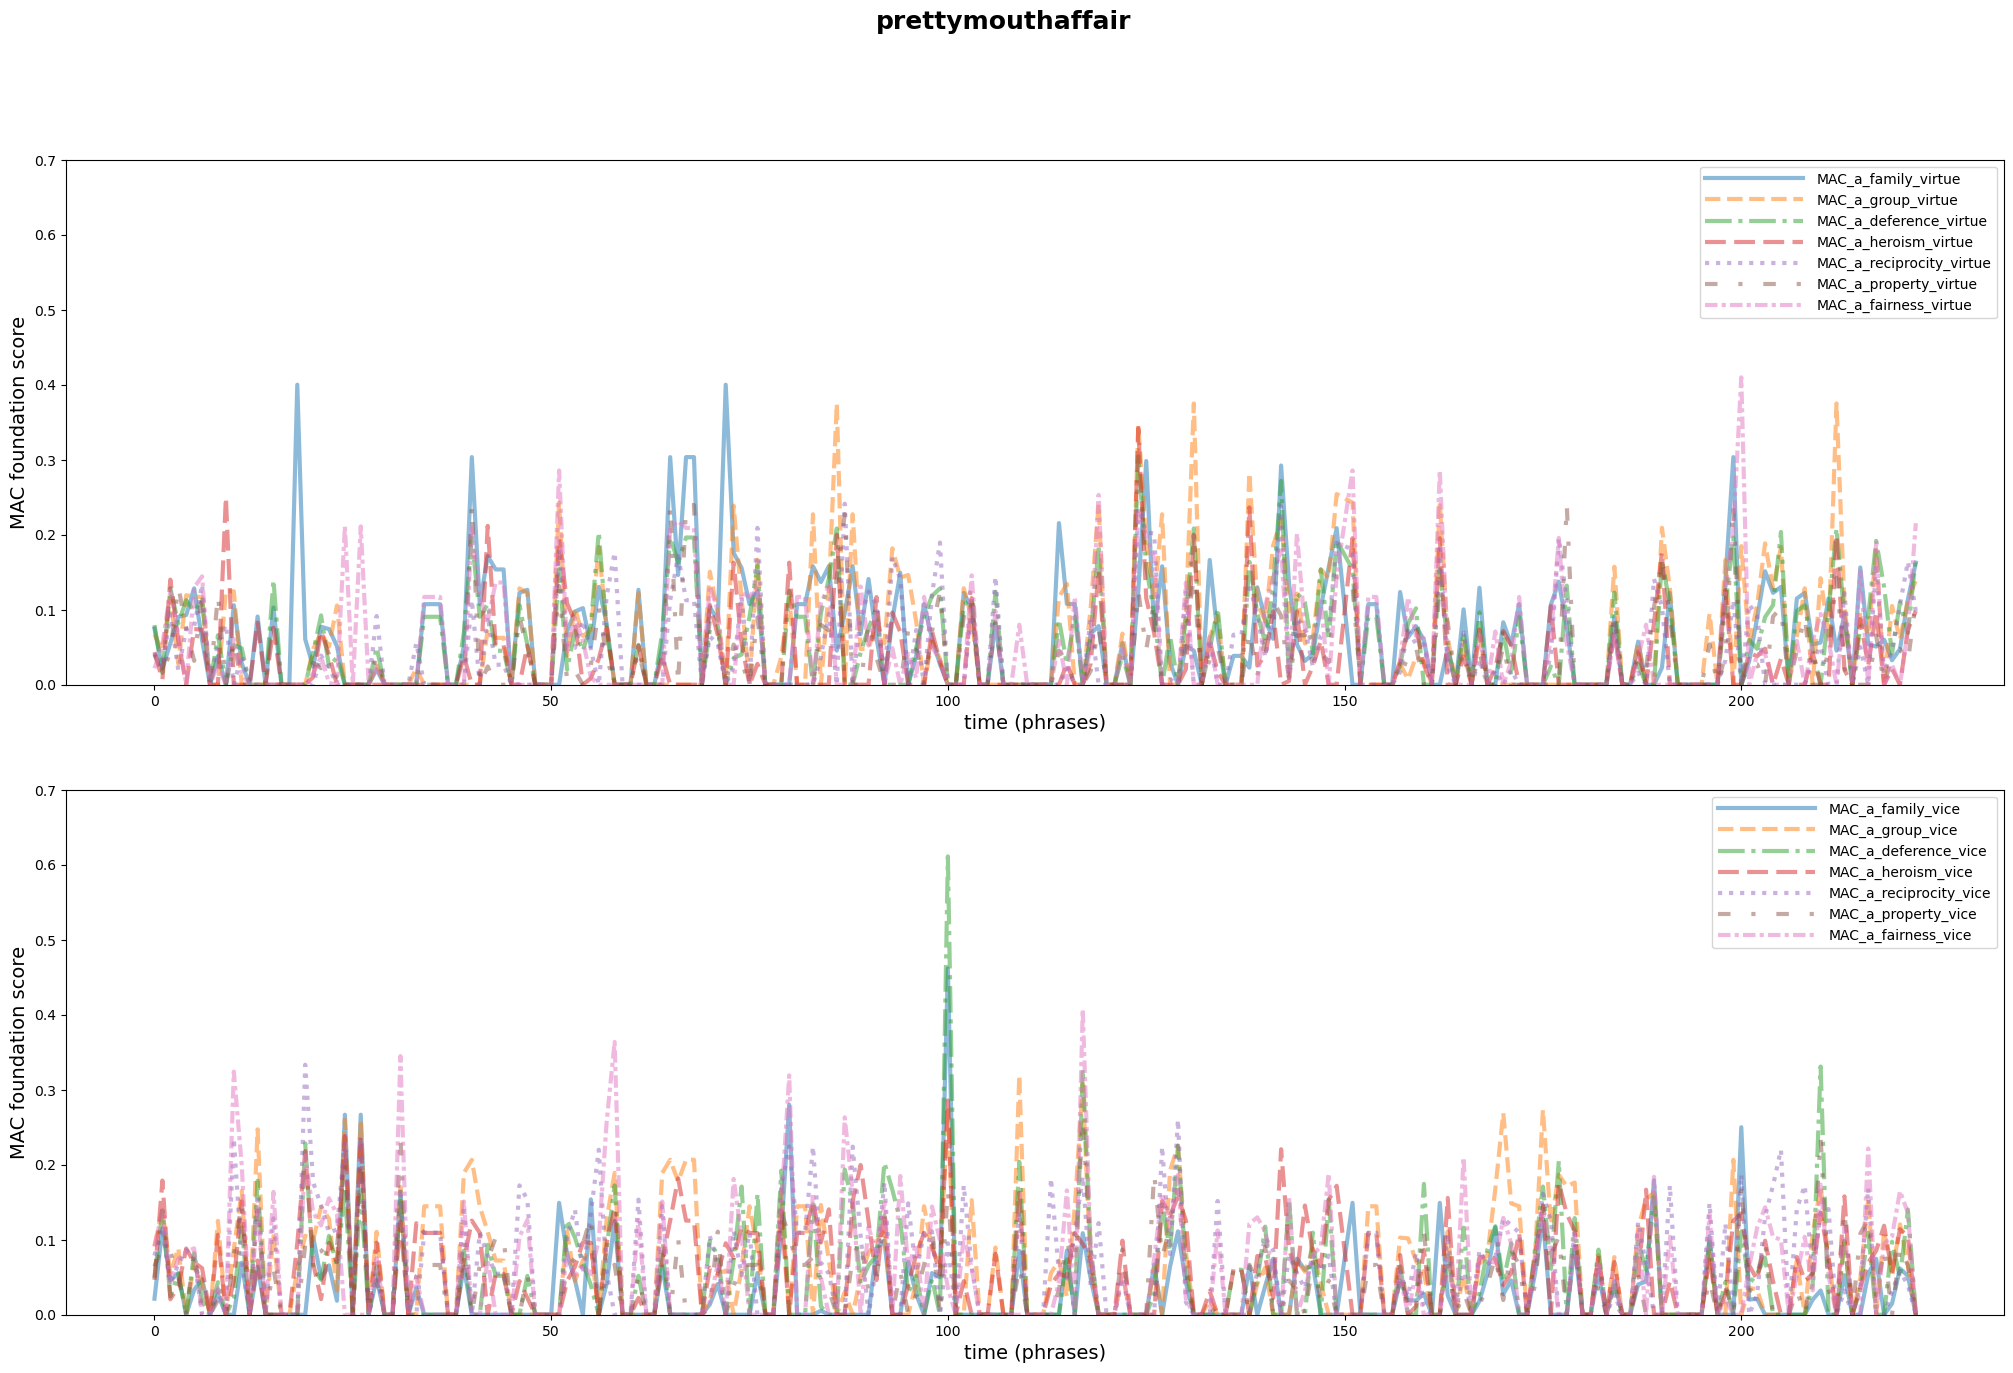

In [3]:
# Set figure size
plt.figure(figsize=(25, 15))

# Add a main title
plt.suptitle(WhichStory, fontsize=18, fontweight='bold')

# First subplot
plt.subplot(2,1, 1)
plt.plot(virtues['MAC_a_family_virtue'], label='MAC_a_family_virtue', linewidth=3, alpha = 0.5, linestyle='-')
plt.plot(virtues['MAC_a_group_virtue'], label='MAC_a_group_virtue', linewidth=3, alpha = 0.5, linestyle='--')
plt.plot(virtues['MAC_a_deference_virtue'], label='MAC_a_deference_virtue', linewidth=3, alpha = 0.5, linestyle='-.')
plt.plot(virtues['MAC_a_heroism_virtue'], label='MAC_a_heroism_virtue', linewidth=3, alpha = 0.5, linestyle=(0, (5, 2)))
plt.plot(virtues['MAC_a_reciprocity_virtue'], label='MAC_a_reciprocity_virtue', linewidth=3, alpha = 0.5, linestyle=':')
plt.plot(virtues['MAC_a_property_virtue'], label='MAC_a_property_virtue', linewidth=3, alpha = 0.5, linestyle=(0, (3, 5, 1, 5)))
plt.plot(virtues['MAC_a_fairness_virtue'], label='MAC_a_fairness_virtue', linewidth=3, alpha = 0.5, linestyle=(0, (3, 1, 1, 1)))
plt.xlabel('time (phrases)', fontsize=14)
plt.ylabel('MAC foundation score', fontsize=14)
plt.ylim(0, 0.7)
# Add legend for the first subplot
plt.legend(handlelength=7, handletextpad=1)

# Second subplot
plt.subplot(2,1, 2)

plt.plot(vices['MAC_a_family_vice'], label='MAC_a_family_vice', linewidth=3, alpha = 0.5, linestyle='-')
plt.plot(vices['MAC_a_group_vice'], label='MAC_a_group_vice', linewidth=3, alpha = 0.5, linestyle='--')
plt.plot(vices['MAC_a_deference_vice'], label='MAC_a_deference_vice', linewidth=3, alpha = 0.5, linestyle='-.')
plt.plot(vices['MAC_a_heroism_vice'], label='MAC_a_heroism_vice', linewidth=3, alpha = 0.5, linestyle=(0, (5, 2)))
plt.plot(vices['MAC_a_reciprocity_vice'], label='MAC_a_reciprocity_vice', linewidth=3, alpha = 0.5, linestyle=':')
plt.plot(vices['MAC_a_property_vice'], label='MAC_a_property_vice', linewidth=3, alpha = 0.5, linestyle=(0, (3, 5, 1, 5)))
plt.plot(vices['MAC_a_fairness_vice'], label='MAC_a_fairness_vice', linewidth=3, alpha = 0.5, linestyle=(0, (3, 1, 1, 1)))
plt.xlabel('time (phrases)', fontsize=14)
plt.ylabel('MAC foundation score', fontsize=14)
plt.ylim(0, 0.7)
# Add legend for the second subplot
plt.legend(handlelength=7, handletextpad=1)

plt.savefig(str(output_dir)+f'/{WhichStory}_MAC.png', dpi=300)  
 
# Show the plots
plt.show()

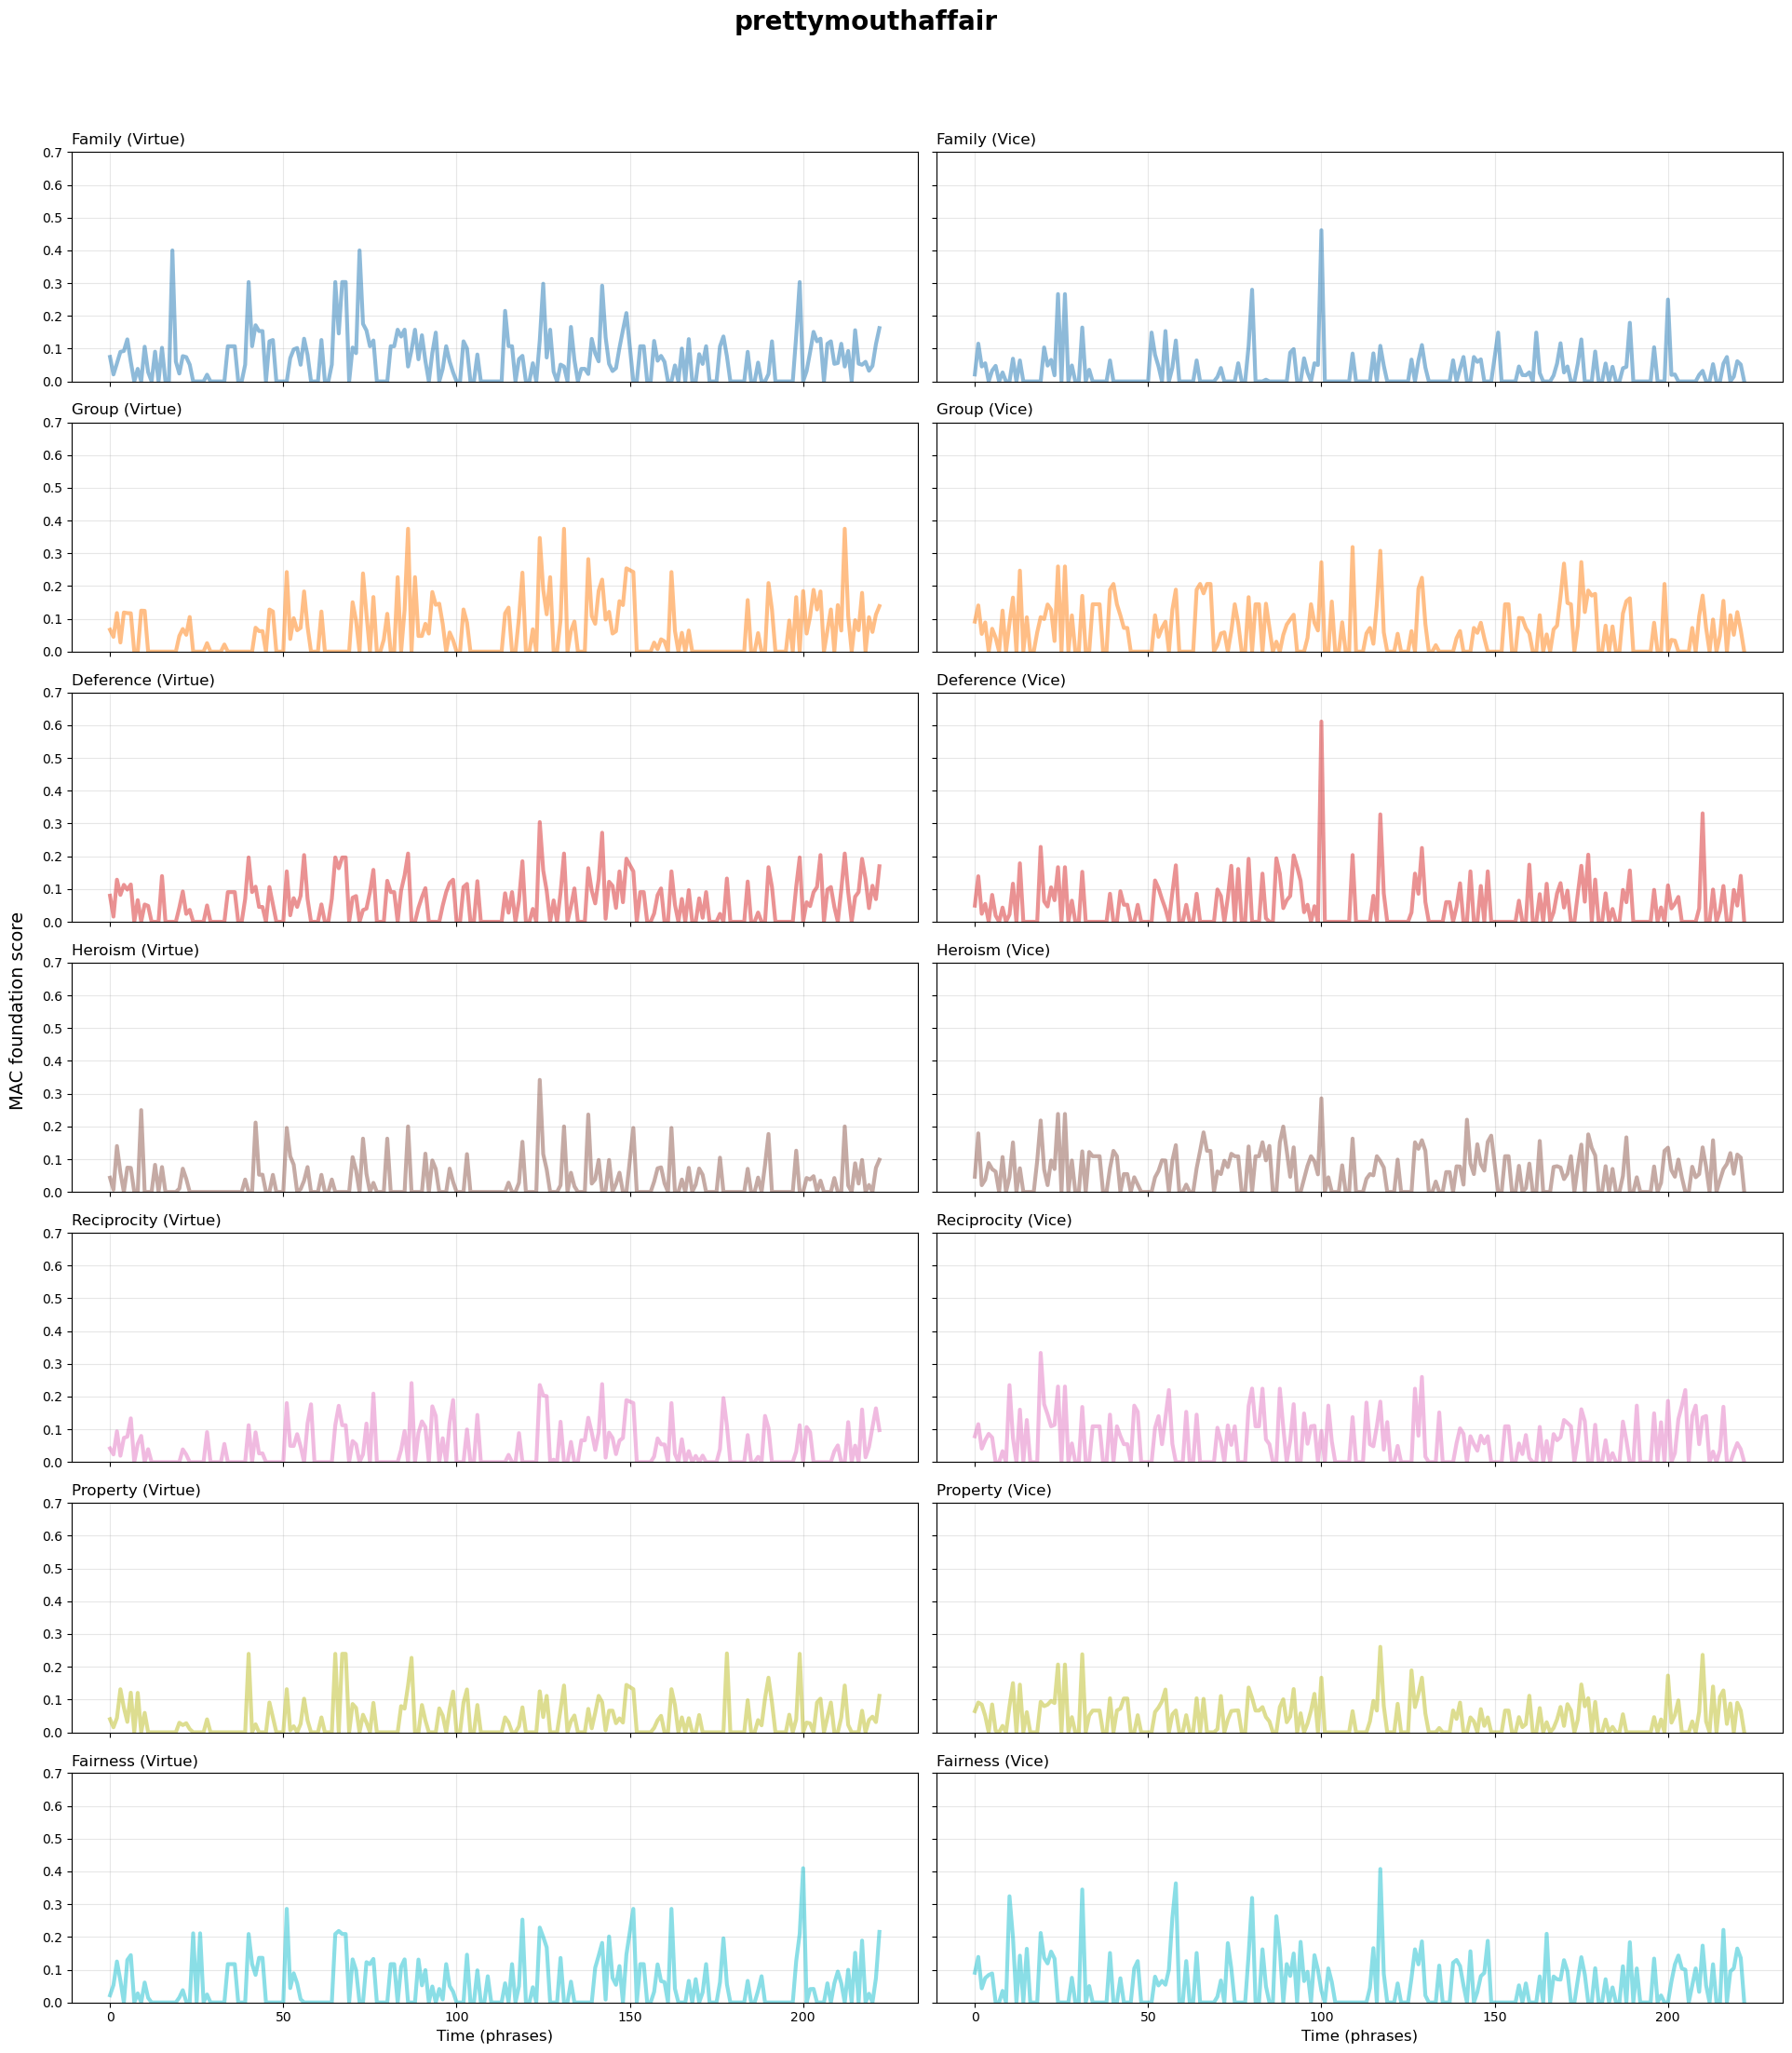

In [4]:
# Define matching virtue/vice pairs
pairs = [
    ('MAC_a_family_virtue', 'MAC_a_family_vice'),
    ('MAC_a_group_virtue', 'MAC_a_group_vice'),
    ('MAC_a_deference_virtue', 'MAC_a_deference_vice'),
    ('MAC_a_heroism_virtue', 'MAC_a_heroism_vice'),
    ('MAC_a_reciprocity_virtue', 'MAC_a_reciprocity_vice'),
    ('MAC_a_property_virtue', 'MAC_a_property_vice'),
    ('MAC_a_fairness_virtue', 'MAC_a_fairness_vice')
]

# Generate distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(pairs)))

# Create subplots: 7 rows × 2 columns
fig, axes = plt.subplots(len(pairs), 2, figsize=(20, 25), sharex=True, sharey=True)
fig.suptitle(WhichStory, fontsize=20, fontweight='bold', y=0.93)

for i, (virtue_col, vice_col) in enumerate(pairs):
    # Left: virtue
    ax_v = axes[i, 0]
    ax_v.plot(virtues[virtue_col], color=colors[i], linewidth=3, alpha=0.5)
    ax_v.set_title(virtue_col.replace('MAC_a_', '').replace('_virtue', '').capitalize() + ' (Virtue)', loc='left', fontsize=12)
    ax_v.grid(alpha=0.3)
    ax_v.set_ylim(0, 0.7)
    if i == len(pairs) - 1:
        ax_v.set_xlabel('Time (phrases)', fontsize=12)

    # Right: vice
    ax_vi = axes[i, 1]
    ax_vi.plot(vices[vice_col], color=colors[i], linewidth=3, alpha=0.5)
    ax_vi.set_title(vice_col.replace('MAC_a_', '').replace('_vice', '').capitalize() + ' (Vice)', loc='left', fontsize=12)
    ax_vi.grid(alpha=0.3)
    ax_vi.set_ylim(0, 0.7)
    if i == len(pairs) - 1:
        ax_vi.set_xlabel('Time (phrases)', fontsize=12)

# Shared y label
fig.text(0.04, 0.5, 'MAC foundation score', va='center', rotation='vertical', fontsize=14)

# Adjust spacing
plt.tight_layout(rect=[0.05, 0.05, 1, 0.9])

plt.savefig(str(output_dir)+f'/{WhichStory}_MAC_option2.png', dpi=300)  

plt.show()
